In [3]:
# ============================================================
# NLP TECHNIQUE COMPARISON (COMPACT, READY TO PASTE)
# - Reads 3 CSVs (A=APERTUS, B=GPT sentence-level, C=RoBERTa sentence-level)
# - Cleaning hooks (rename + value recodes)
# - Optional sentence->article aggregation for B and/or C
# - Optional pairwise filter you can toggle ON/OFF
#   * filter excludes ONLY when BOTH labels are in excluded set (e.g., Other/Other)
# - Pairwise agreement (accuracy + Cohen's kappa)
# - Diagnostics + Topic confusion matrices (+ normalized) + agreement by topic
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 0) FILE PATHS + TECHNIQUE NAMES
# -------------------------------
PATH_A = "2025_APERTUS_ANALYSIS.csv"
PATH_B = "2025_GPT_ANALYSIS.csv"
PATH_C = "2025_ROBERTA_ANALYSIS.csv"

NAME_A = "APERTUS"
NAME_B = "GPT"
NAME_C = "Embed+RoBERTa"

# -------------------------------
# 1) COMMON KEY TO ALIGN ARTICLES
# -------------------------------
KEY_COL = "article_id"   # must exist (or be renamed to) in all three standardized dfs

# -------------------------------
# 2) CLEANING HOOKS (EDIT IF NEEDED)
# -------------------------------
CANON_TOPICS = [
    "Foreign Affairs","Culture","Health","Social","Justice","Migration","Defence","Sport","Finance",
    "Economy","Education","Research","Environment","Transports","Energy","Communication","Other"
]
CANON_SENTIMENT = ["POSITIVE","NEGATIVE","NEUTRAL"]
CANON_POPULISM = ["YES","NO"]

RENAME_A = {
    "id":"article_id",
    "pubtime":"date_col",
    "topic_llm":"topic_col",
    "sentiment_public_admin_llm":"sentiment_col",
    "populism_llm":"populism_col",
}
RENAME_B = {
    "article_id_x":"article_id",
    "pubtime":"date_col",
    "t":"topic_col",
    "sp":"sentiment_col",
    "p":"populism_col",
}
RENAME_C = {
    "id":"article_id",
    "pubtime":"date_col",
    "main_theme":"topic_col",
    "sentiment_label":"sentiment_col",
    # if your C has populism, add it here:
    # "populism_label":"populism_col",
}

TOPIC_MAP = {
    "Others": "Other",
}
SENTIMENT_MAP = {
    "negative": "NEGATIVE", "neutral": "NEUTRAL", "positive": "POSITIVE",
    "-1.0": "NEGATIVE", "0.0": "NEUTRAL", "1.0": "POSITIVE",
    -1.0: "NEGATIVE", 0.0: "NEUTRAL", 1.0: "POSITIVE",
}
POPULISM_MAP = {
    "0.0": "NO", "1.0": "YES",
    "0": "NO", "1": "YES",
}

# Sentence-level flags (B and C)
IS_SENTENCE_LEVEL_B = True
IS_SENTENCE_LEVEL_C = True

# -------------------------------
# 3) FILTER TOGGLE (ON/OFF)
# -------------------------------
USE_FILTERS = False  # <- toggle this whenever you want

FILTERS = {
    # Exclude ONLY when BOTH compared labels are in this set
    "topic_col": {"exclude": {"Other"}},
    "sentiment_col": {"exclude": {"NEUTRAL"}},
    "populism_col": {"exclude": {"NO"}},
}

# -------------------------------
# Helpers
# -------------------------------
def _normalize_string(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    return np.nan if x == "" else x

def _apply_mapping(series: pd.Series, mapping: dict):
    return series.map(lambda v: mapping.get(v, mapping.get(_normalize_string(v), v)))

def cohen_kappa(a: pd.Series, b: pd.Series) -> float:
    mask = a.notna() & b.notna()
    a = a[mask].astype(str)
    b = b[mask].astype(str)
    if len(a) == 0:
        return np.nan
    labels = sorted(set(a.unique()).union(set(b.unique())))
    cm = pd.crosstab(a, b, dropna=False).reindex(index=labels, columns=labels, fill_value=0)
    n = cm.values.sum()
    if n == 0:
        return np.nan
    po = np.trace(cm.values) / n
    pe = (cm.sum(axis=1).values @ cm.sum(axis=0).values) / (n * n)
    if pe == 1:
        return 1.0
    return float((po - pe) / (1 - pe))

def standardize_df(df: pd.DataFrame, rename_dict: dict, technique_name: str, dedupe: bool) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns=rename_dict)

    if KEY_COL not in df.columns:
        raise ValueError(f"[{technique_name}] KEY_COL='{KEY_COL}' not found after renaming. Columns: {list(df.columns)}")

    # Normalize string-ish columns if present
    for col in ["date_col","topic_col","sentiment_col","populism_col"]:
        if col in df.columns:
            df[col] = df[col].map(_normalize_string)

    # Date
    if "date_col" in df.columns:
        df["date_col"] = pd.to_datetime(df["date_col"], errors="coerce")

    # Mappings
    if "topic_col" in df.columns:
        df["topic_col"] = _apply_mapping(df["topic_col"], TOPIC_MAP).map(_normalize_string)
    if "sentiment_col" in df.columns:
        df["sentiment_col"] = _apply_mapping(df["sentiment_col"], SENTIMENT_MAP).map(_normalize_string)
    if "populism_col" in df.columns:
        # Populism often numeric; force numeric when possible, then map
        s_num = pd.to_numeric(df["populism_col"], errors="coerce")
        df["populism_col"] = np.where(s_num.notna(), s_num, df["populism_col"])
        df["populism_col"] = _apply_mapping(pd.Series(df["populism_col"]), POPULISM_MAP).map(_normalize_string)

    keep_cols = [KEY_COL] + [c for c in ["date_col","topic_col","sentiment_col","populism_col"] if c in df.columns]
    df = df[keep_cols]

    if dedupe:
        df = df.drop_duplicates(subset=[KEY_COL], keep="first")

    return df

def aggregate_sentence_to_article(df_sent: pd.DataFrame, technique_name: str) -> pd.DataFrame:
    """
    Sentence -> article aggregation:
      - topic: majority vote
      - sentiment: majority vote
      - populism: ANY-YES (if any sentence YES -> YES else NO)  [robust + common]
    """
    df = df_sent.copy()

    if KEY_COL not in df.columns:
        raise ValueError(f"[{technique_name}] Missing KEY_COL='{KEY_COL}' for aggregation.")

    def majority(s):
        s = s.dropna()
        if s.empty:
            return np.nan
        return s.value_counts().index[0]

    agg = {}
    if "date_col" in df.columns:
        agg["date_col"] = ("date_col", "min")
    if "topic_col" in df.columns:
        agg["topic_col"] = ("topic_col", majority)
    if "sentiment_col" in df.columns:
        agg["sentiment_col"] = ("sentiment_col", majority)

    out = df.groupby(KEY_COL, as_index=False).agg(**agg) if agg else df[[KEY_COL]].drop_duplicates()

    # Populism: any YES -> YES else NO (if any NO exists) else NaN
    if "populism_col" in df.columns:
        def agg_pop(s):
            s = s.dropna().astype(str).str.strip().str.upper()
            if s.empty:
                return np.nan
            return "YES" if (s == "YES").any() else ("NO" if (s == "NO").any() else np.nan)
        pop = df.groupby(KEY_COL)["populism_col"].apply(agg_pop)
        out = out.merge(pop.rename("populism_col"), left_on=KEY_COL, right_index=True, how="left")

    return out

def suffix_cols(df, suffix, cols=("date_col","topic_col","sentiment_col","populism_col")):
    df = df.copy()
    ren = {c: f"{c}_{suffix}" for c in cols if c in df.columns}
    return df.rename(columns=ren)

# --- Filtered selection (pairwise/three-way) ---
def _filtered_pair_df(df, col_base: str, s1: str, s2: str):
    c1, c2 = f"{col_base}_{s1}", f"{col_base}_{s2}"
    if c1 not in df.columns or c2 not in df.columns:
        return None, None, None

    tmp = df[[c1, c2]].copy()
    mask = tmp[c1].notna() & tmp[c2].notna()

    if USE_FILTERS:
        excl = FILTERS.get(col_base, {}).get("exclude", set())
        if excl:
            # exclude only if BOTH are excluded labels
            mask &= ~(tmp[c1].isin(excl) & tmp[c2].isin(excl))

    return tmp, mask, (c1, c2)

def _filtered_three_df(df, col_base: str):
    cA, cB, cC = f"{col_base}_A", f"{col_base}_B", f"{col_base}_C"
    if not all(c in df.columns for c in [cA, cB, cC]):
        return None, None, None

    tmp = df[[KEY_COL, cA, cB, cC]].copy()
    mask = tmp[cA].notna() & tmp[cB].notna() & tmp[cC].notna()

    if USE_FILTERS:
        excl = FILTERS.get(col_base, {}).get("exclude", set())
        if excl:
            # exclude only if ALL THREE are excluded labels
            mask &= ~(tmp[cA].isin(excl) & tmp[cB].isin(excl) & tmp[cC].isin(excl))

    return tmp, mask, (cA, cB, cC)

# -------------------------------
# 4) READ + STANDARDIZE + AGGREGATE (B & C supported)
# -------------------------------
df_a_raw = pd.read_csv(PATH_A)
df_b_raw = pd.read_csv(PATH_B)
df_c_raw = pd.read_csv(PATH_C)

df_a = standardize_df(df_a_raw, RENAME_A, NAME_A, dedupe=True)

df_b_std = standardize_df(df_b_raw, RENAME_B, NAME_B, dedupe=not IS_SENTENCE_LEVEL_B)
df_b = aggregate_sentence_to_article(df_b_std, NAME_B) if IS_SENTENCE_LEVEL_B else df_b_std

df_c_std = standardize_df(df_c_raw, RENAME_C, NAME_C, dedupe=not IS_SENTENCE_LEVEL_C)
df_c = aggregate_sentence_to_article(df_c_std, NAME_C) if IS_SENTENCE_LEVEL_C else df_c_std

A = suffix_cols(df_a, "A")
B = suffix_cols(df_b, "B")
C = suffix_cols(df_c, "C")

df_all = A.merge(B, on=KEY_COL, how="inner").merge(C, on=KEY_COL, how="inner")

print("Rows aligned across ALL 3 techniques:", len(df_all))
print("Columns:", df_all.columns.tolist())

# -------------------------------
# 5) AGREEMENT (FILTER-AWARE)
# -------------------------------
def agreement_report(df, col_base: str, s1: str, s2: str):
    tmp, mask, cols = _filtered_pair_df(df, col_base, s1, s2)
    if tmp is None:
        return None
    c1, c2 = cols
    n = int(mask.sum())
    if n == 0:
        return {"pair": f"{s1} vs {s2}", "n": 0, "accuracy": np.nan, "kappa": np.nan}
    acc = float((tmp.loc[mask, c1].astype(str) == tmp.loc[mask, c2].astype(str)).mean())
    kap = cohen_kappa(tmp.loc[mask, c1], tmp.loc[mask, c2])
    return {"pair": f"{s1} vs {s2}", "n": n, "accuracy": acc, "kappa": kap}

def print_agreement_block(title, df, col_base):
    reps = [
        agreement_report(df, col_base, "A", "B"),
        agreement_report(df, col_base, "A", "C"),
        agreement_report(df, col_base, "B", "C"),
    ]
    reps = [r for r in reps if r is not None]
    if not reps:
        print(f"\n{title}: not available (missing columns).")
        return
    rep_df = pd.DataFrame(reps)
    if USE_FILTERS:
        excl = FILTERS.get(col_base, {}).get("exclude", set())
        print(f"\n=== {title} agreement (FILTER ON, exclude only BOTH in {sorted(excl)}) ===")
    else:
        print(f"\n=== {title} agreement (FILTER OFF) ===")
    print(rep_df.to_string(index=False))

print_agreement_block("TOPIC", df_all, "topic_col")
print_agreement_block("SENTIMENT", df_all, "sentiment_col")
print_agreement_block("POPULISM", df_all, "populism_col")

# -------------------------------
# 6) DIAGNOSTICS (FILTER-AWARE)
# -------------------------------
def per_label_agreement(df, col_base, s1, s2, top_n=10):
    tmp, mask, cols = _filtered_pair_df(df, col_base, s1, s2)
    if tmp is None:
        return None
    c1, c2 = cols
    tmp = tmp.loc[mask].copy()
    if tmp.empty:
        return None
    out = []
    for lbl, grp in tmp.groupby(c1):
        n = len(grp)
        agree = (grp[c1].astype(str) == grp[c2].astype(str)).mean()
        out.append((lbl, n, float(agree)))
    out_df = pd.DataFrame(out, columns=[f"label_in_{s1}", "n", "agreement_rate"]).sort_values("agreement_rate", ascending=False)
    return out_df.head(top_n), out_df.tail(top_n)

def top_confusions(df, col_base, s1, s2, top_n=15):
    tmp, mask, cols = _filtered_pair_df(df, col_base, s1, s2)
    if tmp is None:
        return None
    c1, c2 = cols
    tmp = tmp.loc[mask].copy()
    if tmp.empty:
        return None
    ct = pd.crosstab(tmp[c1], tmp[c2])
    for lbl in ct.index.intersection(ct.columns):
        ct.loc[lbl, lbl] = 0
    long = ct.stack().reset_index()
    long.columns = [f"{s1}", f"{s2}", "count"]
    return long[long["count"] > 0].sort_values("count", ascending=False).head(top_n)

def show_pair_diagnostics(df, col_base, pair_name, s1, s2):
    print(f"\n=== Diagnostics: {pair_name} ({col_base}) ===")
    res = per_label_agreement(df, col_base, s1, s2)
    if res is None:
        print("Not available.")
        return
    best, worst = res
    print("\nHighest agreement labels (conditioned on label in first technique):")
    print(best.to_string(index=False))
    print("\nLowest agreement labels (conditioned on label in first technique):")
    print(worst.to_string(index=False))
    conf = top_confusions(df, col_base, s1, s2)
    if conf is not None and not conf.empty:
        print("\nMost frequent disagreements (top confusions):")
        print(conf.to_string(index=False))

# Topic diagnostics
show_pair_diagnostics(df_all, "topic_col", f"{NAME_A} vs {NAME_B}", "A", "B")
show_pair_diagnostics(df_all, "topic_col", f"{NAME_A} vs {NAME_C}", "A", "C")
show_pair_diagnostics(df_all, "topic_col", f"{NAME_B} vs {NAME_C}", "B", "C")

# Sentiment diagnostics
show_pair_diagnostics(df_all, "sentiment_col", f"{NAME_A} vs {NAME_B}", "A", "B")
show_pair_diagnostics(df_all, "sentiment_col", f"{NAME_A} vs {NAME_C}", "A", "C")
show_pair_diagnostics(df_all, "sentiment_col", f"{NAME_B} vs {NAME_C}", "B", "C")

# Populism diagnostics (only if present)
if any(col.startswith("populism_col_") for col in df_all.columns):
    show_pair_diagnostics(df_all, "populism_col", f"{NAME_A} vs {NAME_B}", "A", "B")
    show_pair_diagnostics(df_all, "populism_col", f"{NAME_A} vs {NAME_C}", "A", "C")
    show_pair_diagnostics(df_all, "populism_col", f"{NAME_B} vs {NAME_C}", "B", "C")

# -------------------------------
# 7) HARD CASES (FILTER-AWARE)
# -------------------------------
def all_three_disagree(df, col_base):
    tmp, mask, cols = _filtered_three_df(df, col_base)
    if tmp is None:
        return pd.DataFrame()
    cA, cB, cC = cols
    tmp = tmp.loc[mask].copy()
    if tmp.empty:
        return tmp
    m = (tmp[cA] != tmp[cB]) & (tmp[cA] != tmp[cC]) & (tmp[cB] != tmp[cC])
    return tmp.loc[m].copy()

hard_topics = all_three_disagree(df_all, "topic_col")
print("\n=== Hard cases (ALL THREE disagree) - TOPIC ===")
print(f"Count: {len(hard_topics)}")
print(hard_topics.head(20).to_string(index=False))

hard_sent = all_three_disagree(df_all, "sentiment_col")
print("\n=== Hard cases (ALL THREE disagree) - SENTIMENT ===")
print(f"Count: {len(hard_sent)}")
print(hard_sent.head(20).to_string(index=False))

# -------------------------------
# 8) TOPIC COMPARISON MATRICES (FILTER-AWARE)
# -------------------------------
def topic_confusion_pair(df, s1="A", s2="B", normalize=None):
    col_base = "topic_col"
    tmp, mask, cols = _filtered_pair_df(df, col_base, s1, s2)
    if tmp is None:
        return None
    c1, c2 = cols
    tmp = tmp.loc[mask].copy()
    if tmp.empty:
        return None

    topics = CANON_TOPICS if "CANON_TOPICS" in globals() else sorted(set(tmp[c1]).union(set(tmp[c2])))
    ct = pd.crosstab(tmp[c1], tmp[c2], dropna=False).reindex(index=topics, columns=topics, fill_value=0)

    if normalize is None:
        return ct
    if normalize == "row":
        denom = ct.sum(axis=1).replace(0, np.nan)
        return (ct.div(denom, axis=0)).fillna(0)
    if normalize == "col":
        denom = ct.sum(axis=0).replace(0, np.nan)
        return (ct.div(denom, axis=1)).fillna(0)
    if normalize == "all":
        total = ct.values.sum()
        return ct / total if total > 0 else ct.astype(float)
    raise ValueError("normalize must be one of: None, 'row', 'col', 'all'")

def agreement_by_topic(df, s1="A", s2="B", min_n=30):
    col_base = "topic_col"
    tmp, mask, cols = _filtered_pair_df(df, col_base, s1, s2)
    if tmp is None:
        return None
    c1, c2 = cols
    tmp = tmp.loc[mask].copy()
    if tmp.empty:
        return None

    rows = []
    for topic, grp in tmp.groupby(c1):
        n = len(grp)
        acc = float((grp[c1].astype(str) == grp[c2].astype(str)).mean())
        rows.append((topic, n, acc))

    out = pd.DataFrame(rows, columns=[f"topic_in_{s1}", "n", "agreement_rate"])
    out = out.sort_values(["agreement_rate", "n"], ascending=[False, False])
    out["kept_for_ranking"] = out["n"] >= min_n
    return out

def print_topic_matrix_suite(df, pair_name, s1, s2):
    print(f"\n==================== {pair_name}: TOPIC MATRICES ====================")
    if USE_FILTERS:
        excl = FILTERS.get("topic_col", {}).get("exclude", set())
        print(f"Filter ON: excluded only if BOTH in {sorted(excl)}")
    else:
        print("Filter OFF")

    ct = topic_confusion_pair(df, s1, s2, normalize=None)
    if ct is None:
        print("No data available.")
        return

    print("\n-- Confusion matrix (counts) --")
    print(ct.to_string())

    ct_row = topic_confusion_pair(df, s1, s2, normalize="row")
    print("\n-- Row-normalized (%) P(model2=col | model1=row) --")
    print((ct_row * 100).round(2).to_string())

    abt = agreement_by_topic(df, s1, s2, min_n=30)
    if abt is not None and not abt.empty:
        print("\n-- Agreement by topic (conditioned on model1 label) --")
        print(abt.to_string(index=False))

        ranked = abt[abt["kept_for_ranking"]].copy()
        if not ranked.empty:
            print("\nTop 8 most coherent topics (min_n=30):")
            print(ranked.head(8)[[f"topic_in_{s1}", "n", "agreement_rate"]].to_string(index=False))
            print("\nTop 8 least coherent topics (min_n=30):")
            print(ranked.tail(8).sort_values("agreement_rate")[[f"topic_in_{s1}", "n", "agreement_rate"]].to_string(index=False))

    # Biggest off-diagonal confusions
    ct_off = ct.copy()
    for t in ct_off.index.intersection(ct_off.columns):
        ct_off.loc[t, t] = 0
    long = ct_off.stack().reset_index()
    long.columns = [f"topic_{s1}", f"topic_{s2}", "count"]
    long = long[long["count"] > 0].sort_values("count", ascending=False).head(20)
    if not long.empty:
        print("\n-- Biggest cross-topic confusions (off-diagonal, top 20) --")
        print(long.to_string(index=False))

print_topic_matrix_suite(df_all, f"{NAME_A} vs {NAME_B}", "A", "B")
print_topic_matrix_suite(df_all, f"{NAME_A} vs {NAME_C}", "A", "C")
print_topic_matrix_suite(df_all, f"{NAME_B} vs {NAME_C}", "B", "C")


Rows aligned across ALL 3 techniques: 8635
Columns: ['article_id', 'date_col_A', 'topic_col_A', 'sentiment_col_A', 'populism_col_A', 'date_col_B', 'topic_col_B', 'sentiment_col_B', 'populism_col_B', 'date_col_C', 'topic_col_C', 'sentiment_col_C']

=== TOPIC agreement (FILTER OFF) ===
  pair    n  accuracy    kappa
A vs B 8635  0.438332 0.370031
A vs C 8635  0.342675 0.283052
B vs C 8635  0.294847 0.192588

=== SENTIMENT agreement (FILTER OFF) ===
  pair    n  accuracy    kappa
A vs B 8635  0.619803 0.087408
A vs C 8635  0.584134 0.042903
B vs C 8635  0.667863 0.318976

=== POPULISM agreement (FILTER OFF) ===
  pair    n  accuracy    kappa
A vs B 8635  0.985061 0.104336

=== Diagnostics: APERTUS vs GPT (topic_col) ===

Highest agreement labels (conditioned on label in first technique):
     label_in_A    n  agreement_rate
        Defence  820        0.808537
Foreign Affairs 1339        0.616878
        Justice 1797        0.431831
        Economy  454        0.422907
     Transports  17

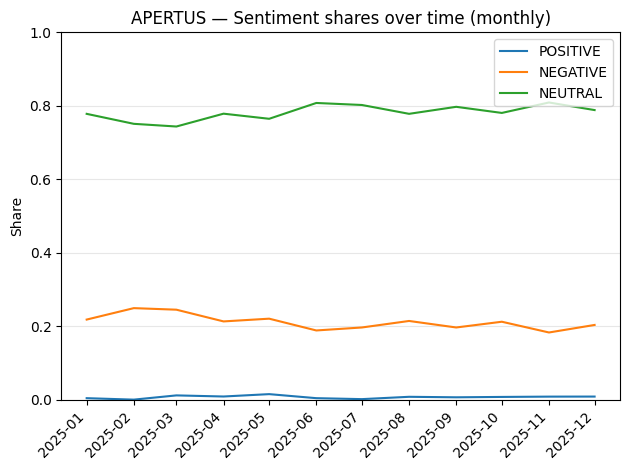

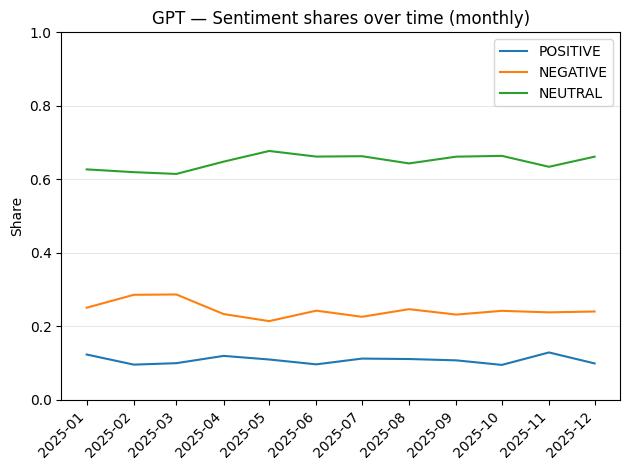

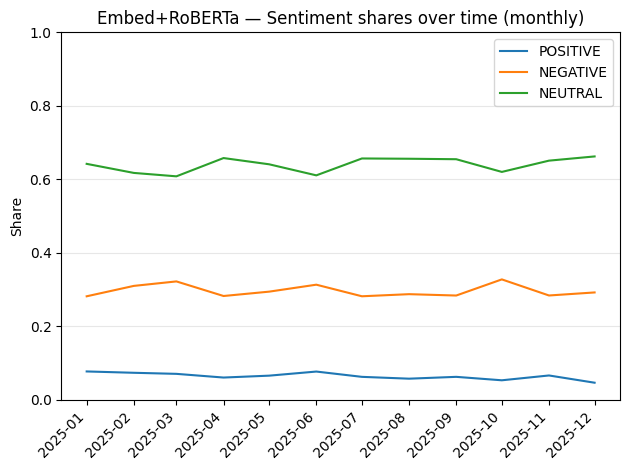

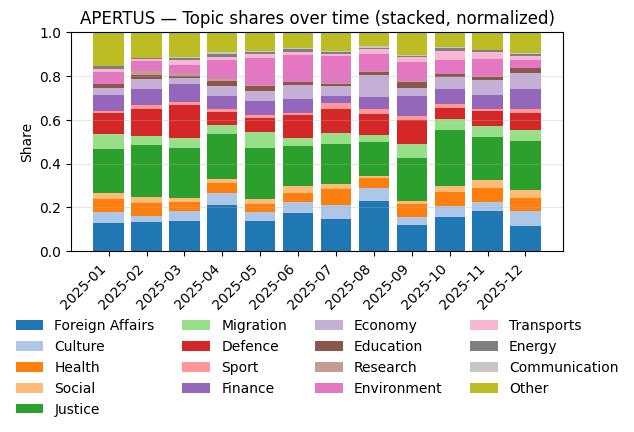

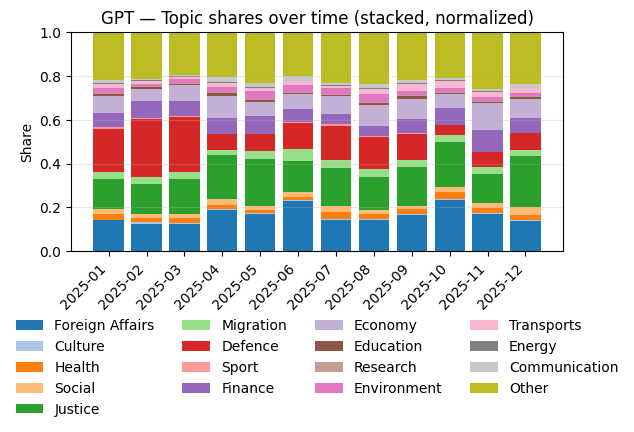

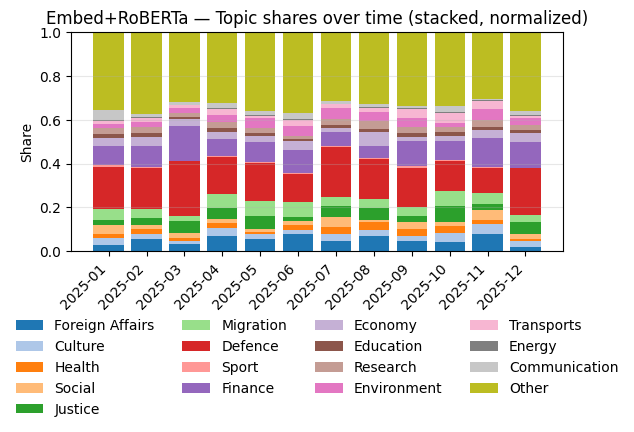

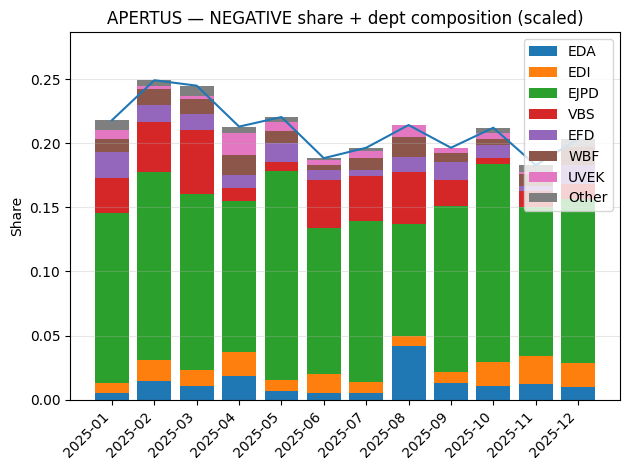

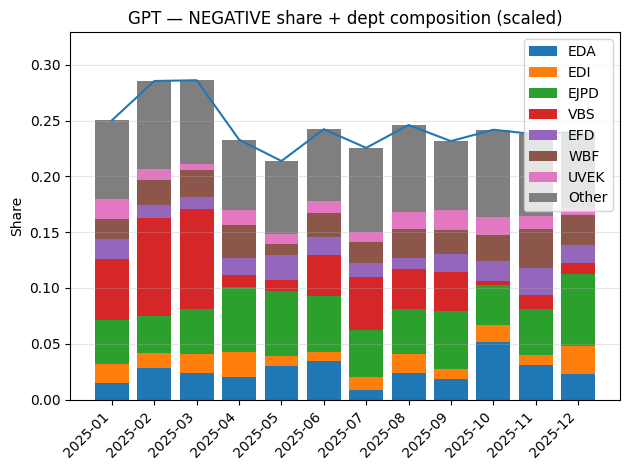

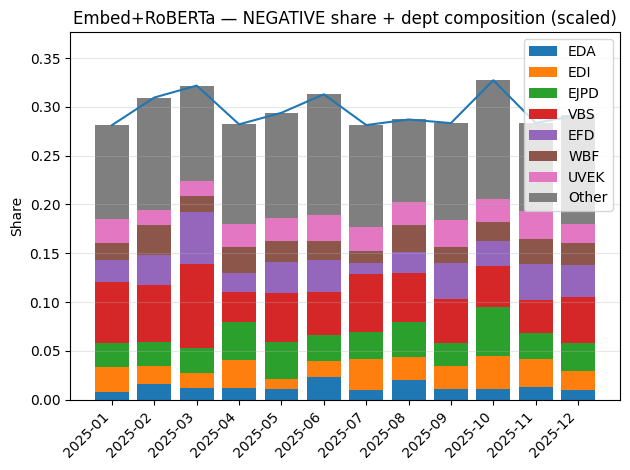

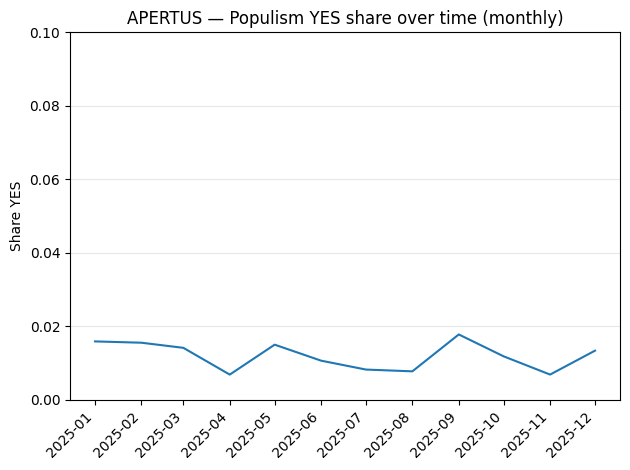

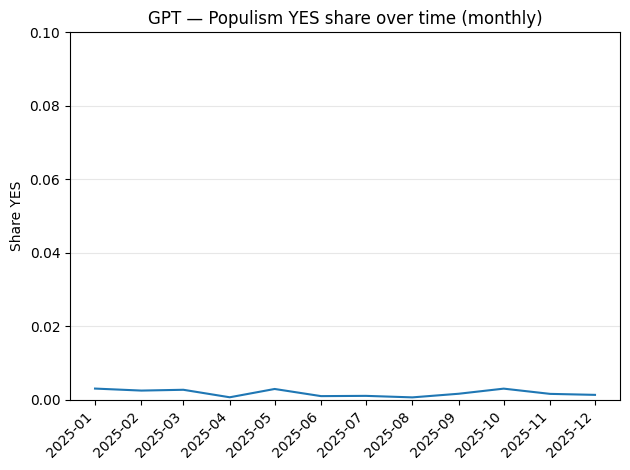

In [5]:
# ============================================================
# GRAPHING BLOCK v2 (matplotlib only) — READY TO PASTE
# Changes vs previous:
# 1) "Negativity line + dept composition under it" is ONE plot:
#    - line = monthly negativity rate
#    - stacked bars are DEPT shares among NEGATIVE, SCALED by negativity rate
#      (so total bar height == negativity rate, like your screenshot)
# 2) Model B and C sentiment/topic plots are computed at SENTENCE level (no aggregation)
# 3) Adds 2 extra plots (Model A and B only): monthly share of Populism == YES
#
# NOTE: This block re-reads the CSVs and standardizes them (so it doesn't depend on whether
# you aggregated B/C earlier). It uses your existing PATH_A/PATH_B/PATH_C, RENAME_*, *_MAPs, etc.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 0) CHECK REQUIRED CONFIG EXISTS
# -------------------------------
required_globals = [
    "PATH_A","PATH_B","PATH_C","NAME_A","NAME_B","NAME_C","KEY_COL",
    "RENAME_A","RENAME_B","RENAME_C","TOPIC_MAP","SENTIMENT_MAP","POPULISM_MAP",
    "CANON_TOPICS","CANON_SENTIMENT","CANON_POPULISM"
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from previous cell: {missing}\n"
                       "Make sure you ran the comparison block first (the compact final version).")

# -------------------------------
# 1) FIXED MAPPINGS (DEPT) + ORDERS
# -------------------------------
TOPIC_TO_DEPT = {
    "Foreign Affairs": "EDA",
    "Culture": "EDI", "Health": "EDI", "Social": "EDI",
    "Justice": "EJPD", "Migration": "EJPD",
    "Defence": "VBS", "Sport": "VBS",
    "Finance": "EFD",
    "Economy": "WBF", "Education": "WBF", "Research": "WBF",
    "Environment": "UVEK", "Transports": "UVEK", "Energy": "UVEK", "Communication": "UVEK",
    "Other": "Other",
}

TOPICS_ORDER = CANON_TOPICS
SENTIMENT_ORDER = CANON_SENTIMENT
DEPT_ORDER = ["EDA","EDI","EJPD","VBS","EFD","WBF","UVEK","Other"]

# -------------------------------
# 2) FIXED COLORS (CONSISTENT ACROSS ALL PLOTS)
# -------------------------------
def _make_color_map(keys, cmap_name="tab20"):
    cmap = plt.get_cmap(cmap_name)
    return {k: cmap(i % cmap.N) for i, k in enumerate(keys)}

TOPIC_COLORS = _make_color_map(TOPICS_ORDER, "tab20")
DEPT_COLORS  = _make_color_map(DEPT_ORDER,  "tab10")
SENT_COLORS  = _make_color_map(SENTIMENT_ORDER, "tab10")

# -------------------------------
# 3) STANDARDIZATION (lightweight, sentence-safe)
# -------------------------------
def _normalize_string(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    return np.nan if x == "" else x

def _apply_mapping(series: pd.Series, mapping: dict):
    return series.map(lambda v: mapping.get(v, mapping.get(_normalize_string(v), v)))

def standardize_df_for_plots(df: pd.DataFrame, rename_dict: dict, technique_name: str, dedupe: bool) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns=rename_dict)

    if KEY_COL not in df.columns:
        raise ValueError(f"[{technique_name}] KEY_COL='{KEY_COL}' not found after renaming. Columns: {list(df.columns)}")

    for col in ["date_col","topic_col","sentiment_col","populism_col"]:
        if col in df.columns:
            df[col] = df[col].map(_normalize_string)

    if "date_col" in df.columns:
        df["date_col"] = pd.to_datetime(df["date_col"], errors="coerce")

    if "topic_col" in df.columns:
        df["topic_col"] = _apply_mapping(df["topic_col"], TOPIC_MAP).map(_normalize_string)

    if "sentiment_col" in df.columns:
        df["sentiment_col"] = _apply_mapping(df["sentiment_col"], SENTIMENT_MAP).map(_normalize_string)

    if "populism_col" in df.columns:
        # robust numeric/text handling
        s_num = pd.to_numeric(df["populism_col"], errors="coerce")
        df["populism_col"] = np.where(s_num.notna(), s_num, df["populism_col"])
        df["populism_col"] = _apply_mapping(pd.Series(df["populism_col"]), POPULISM_MAP).map(_normalize_string)
        # normalize YES/NO uppercase
        df["populism_col"] = df["populism_col"].astype(str).str.strip().str.upper().replace({"NAN": np.nan})

    keep = [KEY_COL] + [c for c in ["date_col","topic_col","sentiment_col","populism_col"] if c in df.columns]
    df = df[keep]

    if dedupe:
        df = df.drop_duplicates(subset=[KEY_COL], keep="first")

    return df

def to_month_frame(df: pd.DataFrame, technique_name: str) -> pd.DataFrame:
    needed = ["date_col", "topic_col", "sentiment_col"]
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"[{technique_name}] Missing column '{c}' for plots.")
    out = df.copy()
    out = out.dropna(subset=["date_col"])
    out["month"] = out["date_col"].dt.to_period("M").dt.to_timestamp()
    out["dept"] = out["topic_col"].map(TOPIC_TO_DEPT).fillna("Other")
    return out

# -------------------------------
# 4) READ + PREPARE MODEL DATA
# -------------------------------
# A is article-level => dedupe True
dfA = standardize_df_for_plots(pd.read_csv(PATH_A), RENAME_A, NAME_A, dedupe=True)

# B and C MUST be sentence-level for sentiment/topic plots => dedupe False
dfB = standardize_df_for_plots(pd.read_csv(PATH_B), RENAME_B, NAME_B, dedupe=False)
dfC = standardize_df_for_plots(pd.read_csv(PATH_C), RENAME_C, NAME_C, dedupe=False)

mA = to_month_frame(dfA, NAME_A)
mB = to_month_frame(dfB, NAME_B)
mC = to_month_frame(dfC, NAME_C)

# -------------------------------
# 5) TABLE HELPERS (SHARES)
# -------------------------------
def share_table(df, index_col: str, value_col: str, categories: list) -> pd.DataFrame:
    ct = pd.crosstab(df[index_col], df[value_col])
    ct = ct.reindex(columns=categories, fill_value=0)
    shares = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return shares.sort_index()

# -------------------------------
# 6) PLOTS
# -------------------------------
def plot_sentiment_shares_over_time(df_m: pd.DataFrame, model_name: str):
    shares = share_table(df_m, "month", "sentiment_col", SENTIMENT_ORDER)
    if shares.empty:
        print(f"[{model_name}] No data for sentiment plot.")
        return

    fig = plt.figure()
    ax = fig.add_subplot(111)
    for s in shares.columns:
        ax.plot(shares.index, shares[s].values, label=s, color=SENT_COLORS.get(s))
    ax.set_title(f"{model_name} — Sentiment shares over time (monthly)")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="upper right")
    ax.set_xticks(shares.index)
    ax.set_xticklabels([d.strftime("%Y-%m") for d in shares.index], rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_topic_shares_stacked(df_m: pd.DataFrame, model_name: str):
    shares = share_table(df_m, "month", "topic_col", TOPICS_ORDER)
    if shares.empty:
        print(f"[{model_name}] No data for topic plot.")
        return

    x = np.arange(len(shares.index))
    bottom = np.zeros(len(shares.index))

    fig = plt.figure()
    ax = fig.add_subplot(111)

    for t in shares.columns:
        vals = shares[t].values
        ax.bar(x, vals, bottom=bottom, label=t, color=TOPIC_COLORS.get(t))
        bottom += vals

    ax.set_title(f"{model_name} — Topic shares over time (stacked, normalized)")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share")
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%Y-%m") for d in shares.index], rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
    plt.tight_layout()
    plt.show()

def plot_negativity_line_plus_dept_scaled(df_m: pd.DataFrame, model_name: str):
    """
    ONE plot:
      - line: negativity rate (NEGATIVE / total) per month
      - stacked bars: dept shares among NEGATIVE, SCALED by negativity rate
        => total bar height == negativity rate (matches your screenshot)
    """
    # totals per month
    total = df_m.groupby("month").size().sort_index()
    if total.empty:
        print(f"[{model_name}] No data for negativity plot.")
        return

    neg_df = df_m[df_m["sentiment_col"] == "NEGATIVE"].copy()
    neg_count = neg_df.groupby("month").size().reindex(total.index).fillna(0)
    neg_rate = (neg_count / total).fillna(0)

    # dept shares among NEGATIVE (normalized within negatives)
    if neg_df.empty:
        dept_sh = pd.DataFrame(index=total.index, columns=DEPT_ORDER).fillna(0)
    else:
        dept_sh = share_table(neg_df, "month", "dept", DEPT_ORDER).reindex(total.index).fillna(0)

    # scale bars by negativity rate
    dept_scaled = dept_sh.mul(neg_rate, axis=0)

    months = total.index
    x = np.arange(len(months))
    bottom = np.zeros(len(months))

    fig = plt.figure()
    ax = fig.add_subplot(111)

    # stacked bars (scaled)
    for d in DEPT_ORDER:
        vals = dept_scaled[d].values if d in dept_scaled.columns else np.zeros(len(months))
        ax.bar(x, vals, bottom=bottom, label=d, color=DEPT_COLORS.get(d))
        bottom += vals

    # negativity line
    ax.plot(x, neg_rate.values)

    ax.set_title(f"{model_name} — NEGATIVE share + dept composition (scaled)")
    ax.set_ylabel("Share")
    ax.set_ylim(0, max(0.01, float(neg_rate.max()) * 1.15))
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%Y-%m") for d in months], rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

def plot_populism_yes_share_over_time(df: pd.DataFrame, model_name: str):
    """
    Monthly share of populism == YES (among non-missing populism rows).
    Intended for A and B only (as requested).
    """
    if "populism_col" not in df.columns:
        print(f"[{model_name}] No populism_col available.")
        return

    tmp = df.copy()
    tmp = tmp.dropna(subset=["date_col"])
    tmp["month"] = tmp["date_col"].dt.to_period("M").dt.to_timestamp()

    # keep only rows with non-missing populism
    tmp = tmp.dropna(subset=["populism_col"])
    if tmp.empty:
        print(f"[{model_name}] No non-missing populism rows.")
        return

    # share YES among (YES/NO)
    tmp["pop"] = tmp["populism_col"].astype(str).str.strip().str.upper()
    grp = tmp.groupby("month")["pop"]
    yes_share = grp.apply(lambda s: (s == "YES").mean()).sort_index()

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(yes_share.index, yes_share.values)
    ax.set_title(f"{model_name} — Populism YES share over time (monthly)")
    ax.set_ylim(0, 0.1)
    ax.set_ylabel("Share YES")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks(yes_share.index)
    ax.set_xticklabels([d.strftime("%Y-%m") for d in yes_share.index], rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# -------------------------------
# 7) RUN PLOTS
# -------------------------------
# 1) Sentiment shares over time (A article-level; B/C sentence-level)
plot_sentiment_shares_over_time(mA, NAME_A)
plot_sentiment_shares_over_time(mB, NAME_B)
plot_sentiment_shares_over_time(mC, NAME_C)

# 2) Topic shares over time (A article-level; B/C sentence-level)
plot_topic_shares_stacked(mA, NAME_A)
plot_topic_shares_stacked(mB, NAME_B)
plot_topic_shares_stacked(mC, NAME_C)

# 3) Negativity line + dept composition (scaled) — ONE plot per model
plot_negativity_line_plus_dept_scaled(mA, NAME_A)
plot_negativity_line_plus_dept_scaled(mB, NAME_B)
plot_negativity_line_plus_dept_scaled(mC, NAME_C)

# 4) Populism YES share over time — Model A and B only (as requested)
plot_populism_yes_share_over_time(dfA, NAME_A)  # article-level
plot_populism_yes_share_over_time(dfB, NAME_B)  # sentence-level
